In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout



In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set global seeds for total reproducibility
SEED = 42 
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

class DataLoader:
    def __init__(self, path, seed=42):
        self.path = path
        self.seed = seed # Added seed attribute
        self.df = None
        self.train_gen = None
        self.val_gen = None
        self.total_images = 0

    def prepare_data(self):
        files = [f for f in os.listdir(self.path) if f.endswith('.jpg')]
        self.total_images = len(files)
        
        data = []
        for f in files:
            try:
                age = int(f.split('_')[0])
                if age <= 18: label = 'Child'
                elif age <= 30: label = 'Young Adult'
                elif age <= 55: label = 'Adult'
                else: label = 'Senior'
                data.append({'filename': f, 'age': age, 'label': label})
            except (IndexError, ValueError):
                continue
        
        self.df = pd.DataFrame(data)
        
        # 1. Added validation_split and a consistent rescale
        datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
        
        # 2. Added 'seed' to the flow_from_dataframe calls
        # This ensures the 80/20 split is the same every time you run it
        self.train_gen = datagen.flow_from_dataframe(
            dataframe=self.df,
            directory=self.path,
            x_col='filename',
            y_col='label',
            target_size=(224, 224),
            batch_size=32,
            class_mode='categorical',
            subset='training',
            shuffle=True,
            seed=self.seed # Applied here
        )
        
        self.val_gen = datagen.flow_from_dataframe(
            dataframe=self.df,
            directory=self.path,
            x_col='filename',
            y_col='label',
            target_size=(224, 224),
            batch_size=32,
            class_mode='categorical',
            subset='validation',
            shuffle=False,
            seed=self.seed # Applied here
        )

    def stats(self):
        print(f"--- Data Loader Statistics (Seed: {self.seed}) ---")
        print(f"Total files found in directory: {self.total_images}")
        print(f"Validated images in DataFrame:  {len(self.df)}")
        print(f"Training samples:               {self.train_gen.samples}")
        print(f"Validation samples:             {self.val_gen.samples}")
        print(f"Number of Classes:              {len(self.train_gen.class_indices)}")
        print(f"Class Names:                    {list(self.train_gen.class_indices.keys())}")

# --- Execution ---
loader = DataLoader('./data/UTKFace/', seed=42)
loader.prepare_data()
loader.stats()

Found 18967 validated image filenames belonging to 4 classes.
Found 4741 validated image filenames belonging to 4 classes.
--- Data Loader Statistics (Seed: 42) ---
Total files found in directory: 23708
Validated images in DataFrame:  23708
Training samples:               18967
Validation samples:             4741
Number of Classes:              4
Class Names:                    ['Adult', 'Child', 'Senior', 'Young Adult']


--- Class Distribution ---
label
Young Adult    8166
Adult          7671
Child          4495
Senior         3376
Name: count, dtype: int64


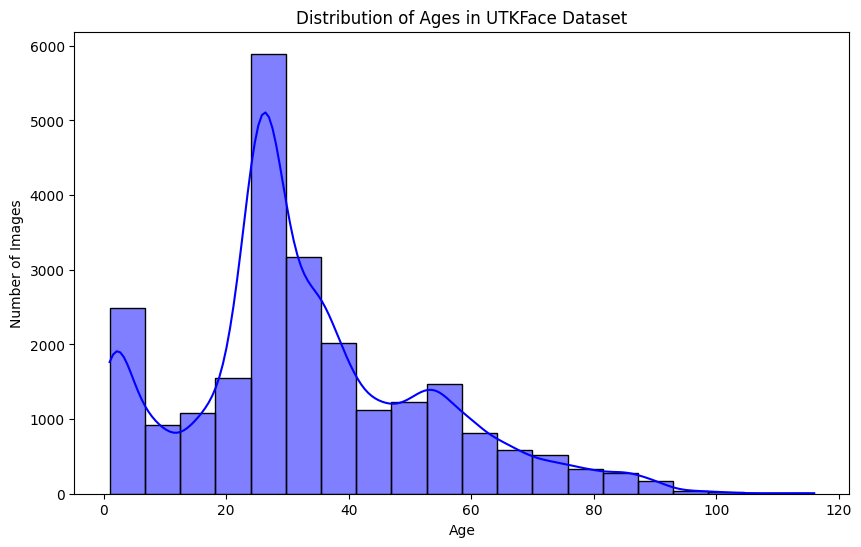

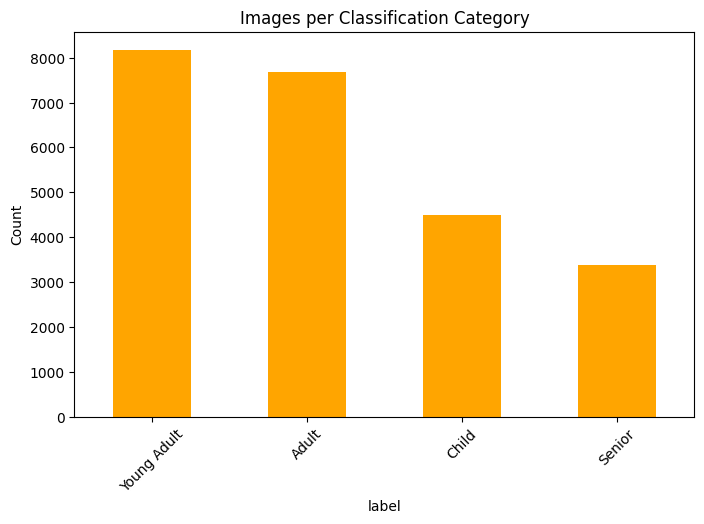

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Show the Classes and Counts
print("--- Class Distribution ---")
# This shows exactly how many images are in each category we created
print(df['label'].value_counts())

# 2. Create the Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20, kde=True, color='blue')
plt.title('Distribution of Ages in UTKFace Dataset')
plt.xlabel('Age')
plt.ylabel('Number of Images')
plt.show()

# 3. Create a Bar Chart for the Classes
plt.figure(figsize=(8, 5))
df['label'].value_counts().plot(kind='bar', color='orange')
plt.title('Images per Classification Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

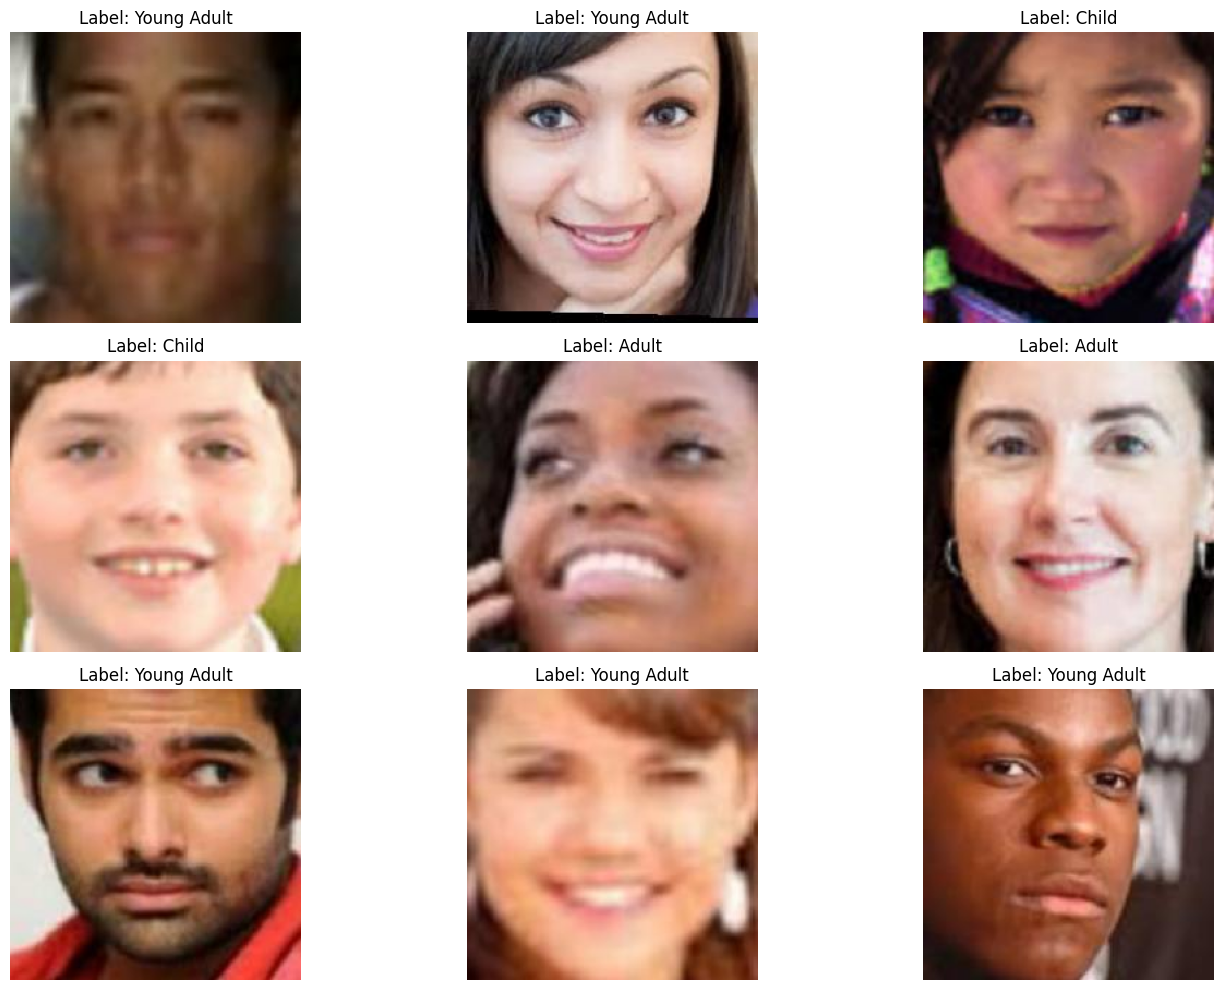

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Get a batch of images and labels
images, labels = next(loader.train_gen)

# 2. Setup the plot
plt.figure(figsize=(15, 10))
class_names = list(loader.train_gen.class_indices.keys())

# 3. Show the first 9 images from the batch
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    
    # Get the label name (it's in One-Hot format, so we use argmax)
    label_index = np.argmax(labels[i])
    plt.title(f"Label: {class_names[label_index]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras import layers, models, callbacks

# 1. Build the "Handmade" CNN Model
model = models.Sequential([
    # Input Layer + First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Second Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Third Block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Fourth Block for deeper feature extraction
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Flattening and Dense Layers
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Essential for academic integrity—prevents "cheating" by memorization
    layers.Dense(4, activation='softmax') # 4 classes: Child, Young Adult, Adult, Senior
])

# 2. Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Add an Early Stopping Callback
# This stops training automatically if the model stops improving, saving you time!
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 4. Start Training
print("Model initialized. Starting the training loop...")
history = model.fit(
    loader.train_gen,
    validation_data=loader.val_gen,
    epochs=15, 
    callbacks=[early_stop]
)

/home/mamdouh_salem/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1777601906.736996   40438 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3620 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model initialized. Starting the training loop...
Epoch 1/15


I0000 00:00:1777601908.136430   40438 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1777601910.233774   43786 service.cc:153] XLA service 0x7f4570039840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777601910.233812   43786 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 12.9.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777601910.312968   43786 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777601910.716661   43786 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1777601910.784294   43786 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3700__.69
I0000 00:00:1777601922.857946   43786 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the p

411/593 ━━━━━━━━━━━━━━━━━━━━ 19s 105ms/step - accuracy: 0.4226 - loss: 4.2590

I0000 00:00:1777601966.711180   43788 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3700__.69


593/593 ━━━━━━━━━━━━━━━━━━━━ 98s 141ms/step - accuracy: 0.5171 - loss: 1.5201 - val_accuracy: 0.5997 - val_loss: 0.8953
Epoch 2/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 67s 113ms/step - accuracy: 0.6251 - loss: 0.8778 - val_accuracy: 0.6729 - val_loss: 0.7653
Epoch 3/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 67s 114ms/step - accuracy: 0.6563 - loss: 0.7932 - val_accuracy: 0.6203 - val_loss: 0.8934
Epoch 4/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 67s 113ms/step - accuracy: 0.6755 - loss: 0.7524 - val_accuracy: 0.5817 - val_loss: 1.2594
Epoch 5/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 67s 113ms/step - accuracy: 0.6933 - loss: 0.7129 - val_accuracy: 0.6345 - val_loss: 0.8542


Generating predictions...
149/149 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step


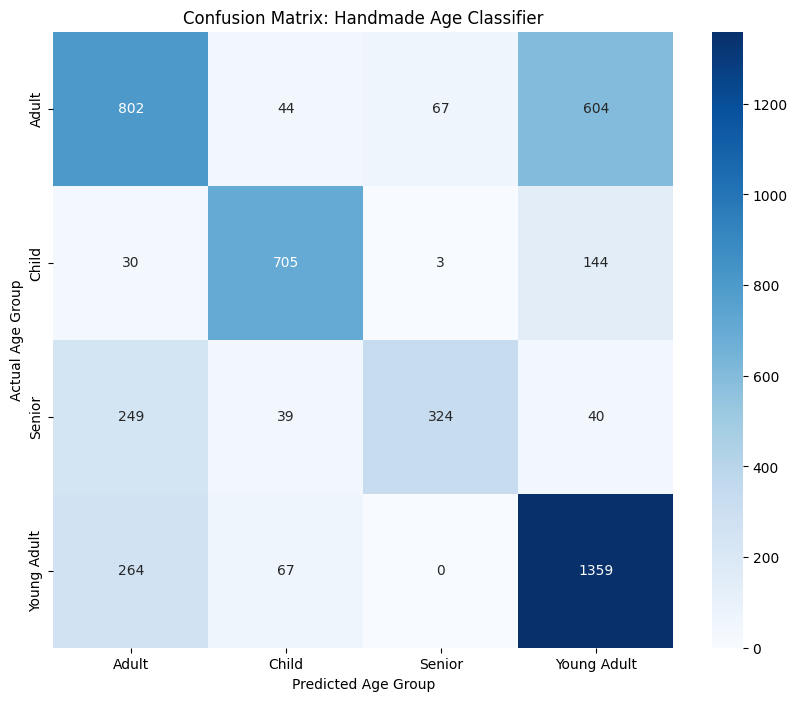


Detailed Classification Report:
              precision    recall  f1-score   support

       Adult       0.60      0.53      0.56      1517
       Child       0.82      0.80      0.81       882
      Senior       0.82      0.50      0.62       652
 Young Adult       0.63      0.80      0.71      1690

    accuracy                           0.67      4741
   macro avg       0.72      0.66      0.68      4741
weighted avg       0.68      0.67      0.67      4741



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get predictions for the validation set
# We use loader.val_gen which we locked with SEED=42 earlier
print("Generating predictions...")
Y_pred = model.predict(loader.val_gen)
y_pred = np.argmax(Y_pred, axis=1)

# 2. Get the true labels
y_true = loader.val_gen.classes
class_labels = list(loader.train_gen.class_indices.keys())

# 3. Create the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix: Handmade Age Classifier')
plt.ylabel('Actual Age Group')
plt.xlabel('Predicted Age Group')
plt.show()

# 5. Print a detailed report
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

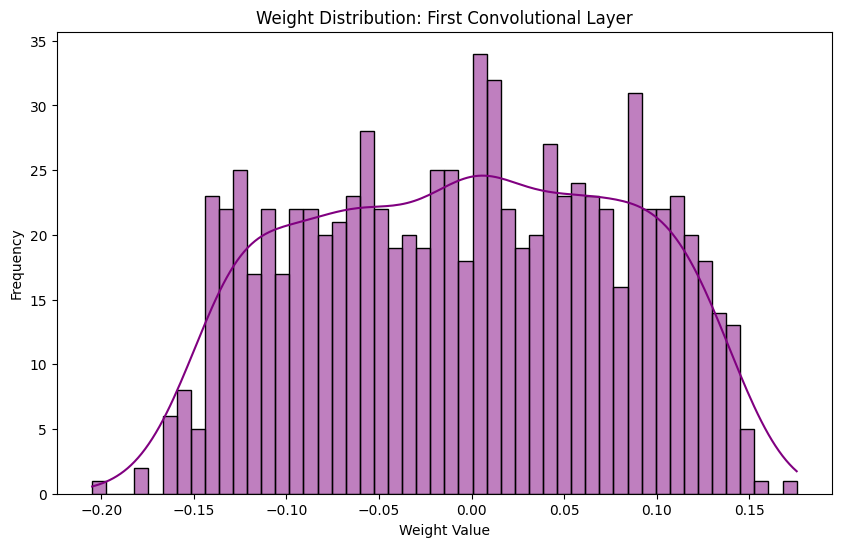

Total parameters in this layer: 864
Mean weight value: -0.004042
Standard deviation: 0.084058


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the weights from the very first convolutional layer
# layers[0] is your first Conv2D layer
weights, biases = model.layers[0].get_weights()

# 2. Flatten the weights to a 1D array for plotting
weights_flat = weights.flatten()

# 3. Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(weights_flat, bins=50, kde=True, color='purple')
plt.title('Weight Distribution: First Convolutional Layer')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.show()

print(f"Total parameters in this layer: {weights_flat.size}")
print(f"Mean weight value: {weights_flat.mean():.6f}")
print(f"Standard deviation: {weights_flat.std():.6f}")

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_age(img_path, model, loader):
    # 1. Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Normalize to 0-1

    # 2. Make Prediction
    predictions = model.predict(img_array)
    class_names = list(loader.train_gen.class_indices.keys())
    
    # 3. Get results
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(predictions) * 100

    # 4. Display
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()
    
    # Print probability for all classes
    for i, class_name in enumerate(class_names):
        print(f"{class_name}: {predictions[0][i]*100:.2f}%")

# --- Test it! ---
# Replace with a path to a specific image from your data folder or a new photo
test_path = './data/UTKFace/25_0_0_20170117150153013.jpg' 
predict_age(test_path, model, loader)

FileNotFoundError: [Errno 2] No such file or directory: './data/UTKFace/25_0_0_20170117150153013.jpg'